# Day 0 — From One Model Call to One Graph Node

**Time:** 35–45 minutes  
**Build:** a one-node code explainer  
**New words:** model call, state, node, edge

You do not need to understand MLflow internals today. It is the shared doorway to the model. First get a response; then make the same input and output explicit as graph state.

## Checkpoint 1 — Get the first response

Before running: predict whether the model will identify the exact bug or only explain the code.

In [1]:
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(
    base_url="http://127.0.0.1:5001/gateway/mlflow/v1",
    api_key="not-needed",
    model="workshop-gemini",
)

reply = llm.invoke("Explain what an AI agent is in one sentence.")
print(reply.content)

OpenAIConnectionError: Connection error.

## Checkpoint 2 — Meet the running example

The code below solves 0/1 knapsack, where each item may be used once. It looks valid but iterates capacity in the wrong direction. Today we only ask the model to explain it.

In [ ]:
problem_statement = "Choose items within the capacity and maximize value. Each item may be selected at most once."
buggy_code = """n, capacity = map(int, input().split())
items = [tuple(map(int, input().split())) for _ in range(n)]
dp = [0] * (capacity + 1)
for weight, value in items:
    for current in range(weight, capacity + 1):
        dp[current] = max(dp[current], dp[current - weight] + value)
print(dp[capacity])"""

prompt = f"Problem:\n{problem_statement}\n\nCode:\n{buggy_code}\n\nExplain what the code is trying to do."
print(llm.invoke(prompt).content)

The provided code is an implementation of the **0/1 Knapsack Problem**, which is a classic algorithmic problem used in optimization. The goal of the problem is to determine the maximum value of items that can be carried in a knapsack (bag) without exceeding a given weight capacity. Here's a step-by-step breakdown of what the code does:

1. **Input handling**: 
   - The first line takes two integers as input: `n` (the number of items) and `capacity` (the maximum weight the knapsack can hold).
   - The next `n` lines of input are processed into a list called `items`, where each item is represented as a tuple consisting of two integers: `weight` (the weight of the item) and `value` (the value of the item).

2. **Dynamic Programming Array Initialization**:
   - A list `dp` is created with a size of `capacity + 1`, initialized to all zeros. This list will be used to keep track of the maximum value that can be achieved for each possible weight from 0 to `capacity`.

3. **Main Logic**:
   - T

## Checkpoint 3 — Predict the graph

The graph will have one application node. Predict its state before running:

| Field | Present at start? | Updated by the node? |
| --- | --- | --- |
| `problem` | Yes | No |
| `code` | Yes | No |
| `explanation` | No | Yes |

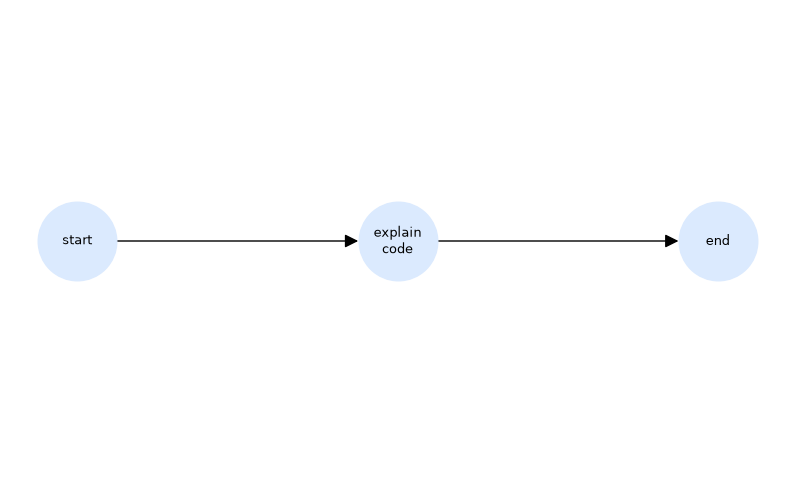

In [ ]:
from typing import TypedDict
from langgraph.graph import END, START, StateGraph
import sys
sys.path.append("../..")
from graph_image import show_graph

class State(TypedDict, total=False):
    problem: str
    code: str
    explanation: str

def explain_code(state: State):
    prompt = f"Problem:\n{state['problem']}\n\nCode:\n{state['code']}\n\nExplain the algorithm and identify anything suspicious."
    return {"explanation": llm.invoke(prompt).content}

builder = StateGraph(State)
builder.add_node("explain_code", explain_code)
builder.add_edge(START, "explain_code")
builder.add_edge("explain_code", END)
graph = builder.compile()
show_graph(graph)

## Checkpoint 4 — Run and inspect state

The test cell calls the graph, not the model. The returned explanation is read from state.

In [ ]:
result = graph.invoke({"problem": problem_statement, "code": buggy_code})
assert result["problem"] == problem_statement
assert result["code"] == buggy_code
assert result["explanation"].strip()
print(result["explanation"])

The code provided implements a solution to the 0/1 Knapsack Problem using dynamic programming. Here’s how the algorithm works, along with any potential issues:

### Explanation of the Algorithm

1. **Input Reading:**
   - The first line reads two integers, `n` (the number of items) and `capacity` (the maximum weight the knapsack can carry).
   - The subsequent `n` lines each contain a pair of integers representing the `weight` and `value` of each item.

2. **Dynamic Programming Array Initialization:**
   - An array `dp` of length `capacity + 1` is created. Each index `i` in this array represents the maximum value that can be attained with a knapsack of capacity `i`. All entries are initialized to `0`.

3. **Dynamic Programming Iteration:**
   - The outer loop iterates over each item represented by its `weight` and `value`.
   - The inner loop iterates through the `dp` array in reverse from `capacity` to `weight`. This reverse iteration ensures that the current item can only be consider

## Intentional failure — Break the state contract

Remove `code` from the input in a copy of the test cell. The node fails because its state contract requires both fields. Restore it before continuing.

**Exit question:** What did the graph add that the direct model call did not?